# Vibe Coding a modern diffusion pipeline (NVIDIA EDM, SR3, Toyota SR)

* Nvidia - Elucidating the Design Space of Diffusion-Based Generative Models - https://arxiv.org/abs/2206.00364
* Toyota - Efficient Burst Super-Resolution with One-step Diffusion - https://arxiv.org/abs/2507.13607
* Google SR3 - Image Super-Resolution via Iterative Refinement - https://arxiv.org/abs/2104.07636


## 1. Install and Import Required Libraries

We will use PyTorch, torchvision, numpy, matplotlib, and tqdm. If running locally, ensure these packages are installed.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.utils as vutils
import base64
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
import random
import time
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision import transforms
from datetime import datetime
from io import BytesIO
from PIL import Image, ImageOps
from tqdm import tqdm
#import cv2
import numpy as np
from PIL import Image
import torchvision.transforms.functional as TF
import torch
import torch.nn as nn
import io
import os
import mlflow
import tempfile
import einx

In [3]:
%env MLFLOW_TRACKING_URI=sqlite:///mlruns.db
# mlflow gc --tracking-uri sqlite:///./mlruns.db
# mlflow ui --backend-store-uri sqlite:///./mlruns.db

env: MLFLOW_TRACKING_URI=sqlite:///mlruns.db


In [4]:
from elucidated_diffusion.elucidated_diffusion import edm_ancestral_sampling_for_diffusion
from elucidated_diffusion.elucidated_diffusion import edm_ancestral_sampling_for_sr
from elucidated_diffusion.elucidated_diffusion import P_mean, P_std, sigma_data, edm_loss_weight
from elucidated_diffusion.ema_helper import EMAHelper,EDMEMAHelper
from elucidated_diffusion.models.chatgpt_diffusion_unet import ChatGPTDiffusionUNet128
from elucidated_diffusion.models.claude_skip_attention import SkipAttentionUNet
# from elucidated_diffusion.models.claude_cascaded_vit import FlexibleCascadedViT # old version
#from elucidated_diffusion.models.claude_cascaded_vit import MultiScaleSharedViT # old version in pixel space
#from elucidated_diffusion.models.claude_cascaded_vit import SemanticCascadeViT
from elucidated_diffusion.models.semantic_and_pixel_cascaded_vit import HybridCascadedViT
from elucidated_diffusion.models.claude_diffusion_ViTEnhancedUNet64 import create_vit_enhanced_unet
from elucidated_diffusion.models.claude_diffusion_ViTGradualTransition import create_gradual_transition_unet
from elucidated_diffusion.models.claude_diffusion_ViTGradualTransition import create_gradual_transition_unet
from elucidated_diffusion.models.claude_SemanticCoordinatorViTUNet import create_semantic_coordinator
from elucidated_diffusion.dataset_helpers import AugmentedHRLRDataset,TwoImageDebugDataset
from elucidated_diffusion.checkpoint_helper import load_checkpoint, save_checkpoint, show_model_info
from elucidated_diffusion.models.claude_cortical_refiner import CorticalRefinerUNet
from elucidated_diffusion.models.claude_cortical_refiner_noskip_ablation import CorticalRefinerUNetNoskipAblation

#from elucidated_diffusion.checkpoint_helper import load_checkpoint, save_checkpoint, show_model_info


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
HR = 256
LR = 64
device

device(type='cuda')

## 3. Define a Vision Model for a Diffusion Model Architecture

* **Sinusoidal Timestep Embedding**
  * → Encodes diffusion step (time) as a multi-frequency vector. Lets the model “know” how much noise is present and what stage of denoising it’s in.
* **Optional Self-Attention at Lower Resolutions (e.g. 16×16)**
  * → Lets distant parts of the image “talk to each other,” useful for global structure (symmetry, object coherence). Limited to low-res maps to save compute.
* **SiLU/Swish activations**
  * → Smooth nonlinearities, empirically better than ReLU in diffusion U-Nets.

## 4. Load and Preprocess Dataset

We will use any image directory for demonstration. The images will be normalized to [-1, 1] as required by most diffusion models.

In [7]:
def get_dataset_and_loader(dataset_name,img_size,thm_size,batch_size = None):
    if dataset_name == 'debug':
        ds = TwoImageDebugDataset(img_size,thm_size)
    else:
        ds = AugmentedHRLRDataset(f"data/256x256/{dataset_name}",img_size,thm_size)
    if batch_size is None:
        batch_size = 128*128 *2*4 // img_size // img_size
        if batch_size == 0:
            batch_size = 1
    print(f"Using batch size of {batch_size}")
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=0)
    return ds, dl

## 4. Implement the Forward Diffusion Process

The forward process gradually adds Gaussian noise to the data over a fixed number of timesteps.

## 6. Elucidated Diffusion Model (EDM) Implementation

This section implements the EDM as described in the paper (2206.00364v2.pdf), including its unique noise schedule, loss weighting, and sampling procedure.

### 6a. EDM loss and schedule functions.

### 6b. EDM Sampling / Reconstruction

In [8]:
from elucidated_diffusion.image_helpers import pil_to_data_url, html_for_images

In [9]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

def plusminusone_to_zerotoone(t):
    return ((t + 1)/2).clamp(0,1)

def generate_images(model_edm, num_steps=15, batch_size=20, img_shape = (3,64,64)):
    to_pil = transforms.ToPILImage()
    with torch.no_grad():
        samples = edm_ancestral_sampling_for_diffusion(model_edm, num_steps=num_steps, batch_size=batch_size, img_shape=img_shape).cpu()
        pil_images = [to_pil(img) for img in plusminusone_to_zerotoone(samples)]
    return pil_images

def generate_sr(model_edm, lowres_reference_batch, highres_reference_batch= None, img_shape=(3,256,256)):
    to_pil = transforms.ToPILImage()
    orig_imgs=[]
    lowres_imgs=[]
    predicted_imgs=[]
    with torch.no_grad():
        #hr,lr,orig = next(iter(sr_dl))
        #lr_64 = lr.to(device)
        batch_size = 10
        lowres_reference_batch = lowres_reference_batch[0:batch_size]
        lr_64 = lowres_reference_batch.to(device)
        print(f"in generate_sr {lr_64.shape}, {batch_size}, {img_shape}")
        samples = edm_ancestral_sampling_for_sr(model_edm, lr_64, num_steps=18, batch_size=batch_size, img_shape=img_shape).cpu()
        orig_imgs = [to_pil(img) for img in plusminusone_to_zerotoone(highres_reference_batch)]
        lowres_imgs = [to_pil(img) for img in plusminusone_to_zerotoone(lr_64)]
        predicted_imgs = [to_pil(img) for img in plusminusone_to_zerotoone(samples)]
        pil_images = [item for group in zip(orig_imgs,lowres_imgs,predicted_imgs) for item in group]
    print(pil_images)
    return pil_images

def sample_html(model, batch_size=12, img_shape=(3,64,64), num_steps=36, title="EDM Samples",min_height=128,sr_resolution=None,sr_dataloader=None):
    imgs = generate_images(model_edm=model, batch_size=batch_size, img_shape=img_shape, num_steps=16)
    h = html_for_images(imgs, title=title, min_height=min_height)
    if sr_resolution:
        from torch.utils.data import DataLoader
        assert isinstance(sr_dataloader,DataLoader)
        hr,lr,orig = next(iter(sr_dataloader))
        imgs = generate_sr(model,lr,hr,img_shape=img_shape)
        h += html_for_images(imgs, title=f"SR {title}", min_height=8)
    return h

#sr_ds,sr_dl= get_dataset_and_loader('pokemon',256,64)
#print(sr_ds[0][1].shape)
#to_pil = transforms.ToPILImage()
#to_pil((sr_ds[0][1].clone()+1)/2)
#next(iter(sr_dl))[1].shape

# 6c. EDM Training Loop 

In [10]:
# # EDM training loop - CORRECTED with proper preconditioning coefficients
# # Following NVIDIA's EDMPrecond implementation exactly

# def train_a_batch(model_edm, optimizer_edm, batch, lr_batch=None):
 
#         x = batch.to(device)
#         lr = lr_batch.to(device) if (lr_batch is not None) else None
        
#         model_edm.train()
        
#         # Log-normal sigma sampling (as in NVIDIA's implementation)
#         rnd_normal = torch.randn([x.shape[0], 1, 1, 1], device=device)
#         sigma = (rnd_normal * P_std + P_mean).exp()
        
#         # Preconditioning coefficients (from NVIDIA's EDMPrecond)
#         c_skip = sigma_data ** 2 / (sigma ** 2 + sigma_data ** 2)
#         c_out = sigma * sigma_data / (sigma ** 2 + sigma_data ** 2).sqrt()
#         c_in = 1 / (sigma_data ** 2 + sigma ** 2).sqrt()
#         c_noise = sigma.log() / 4
        
#         # Add noise: y_noisy = x + σ·n where n ~ N(0,I)
#         noise = torch.randn_like(x) * sigma
#         y_noisy = x + noise
        
#         # Model prediction: F_x = net(c_in * y_noisy, c_noise)
#         c_noise_input = c_noise.view(x.shape[0])
#         F_x = model_edm(c_in * y_noisy, c_noise_input,thumbnail=lr)
        
#         # Preconditioning: D_x = c_skip * y_noisy + c_out * F_x
#         D_x = c_skip * y_noisy + c_out * F_x
        
#         # Loss weight: λ(σ) = (σ² + σ_data²) / (σ·σ_data)²
#         weight = edm_loss_weight(sigma.squeeze(), sigma_data).view(-1, 1, 1, 1)
        
#         # Loss: weighted MSE between preconditioning output and clean image
#         loss = (weight * (D_x - x) ** 2).mean()
        
#         optimizer_edm.zero_grad()
#         loss.backward()
#         optimizer_edm.step()

#         # Track per-sigma-bin loss:
#         if track_per_sigma_bin_loss := True:
#                 with torch.no_grad():
#                         per_pixel_loss = weight * (D_x - x) ** 2
#                         per_sample_loss = per_pixel_loss.mean(dim=(1, 2, 3))  # shape: [B]
#                         loss2 = per_sample_loss.mean()
#                         # sometimes this is false - TODO: figure out why (unstable models?)
#                         assert(torch.allclose(loss,loss2))
#                         if not torch.allclose(loss,loss2):
#                                 print("DEBUG loss {loss}, loss2 {loss2}")
#                         sigma_flat = sigma.view(-1)  # [B]

#                         # Example bins in log-space
#                         sigma_bins = torch.tensor(
#                                 [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0],
#                                 device=sigma.device
#                         )

#                         # bucket indices: [B]
#                         bin_ids = torch.bucketize(sigma_flat, sigma_bins)

#                         # accumulate stats (CPU-friendly)
#                         bin_loss = {}
#                         for b in range(len(sigma_bins) + 1):
#                                 mask = bin_ids == b
#                                 if mask.any():
#                                         bin_loss[b] = per_sample_loss[mask].mean().item()
#                 return loss.item(), sigma_bins, bin_loss

#         return loss.item()





In [11]:
SIGMA_BINS = torch.tensor(
    [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0], device=device
)


def diffusion_loss(model, x, sigma, noise, thumbnail):
    """
    One EDM forward + preconditioning pass at a given (x, sigma, noise),
    with or without thumbnail conditioning. Returns per-sample loss [B]
    rather than a scalar, so callers can both .mean() it for backprop AND
    bucket it by sigma for diagnostics -- from the exact same tensor, so
    the two can never numerically diverge (see note below on the old
    assert).
    """
    c_skip = sigma_data ** 2 / (sigma ** 2 + sigma_data ** 2)
    c_out = sigma * sigma_data / (sigma ** 2 + sigma_data ** 2).sqrt()
    c_in = 1 / (sigma_data ** 2 + sigma ** 2).sqrt()
    c_noise = sigma.log() / 4

    y_noisy = x + noise
    c_noise_input = c_noise.view(x.shape[0])
    if thumbnail is not None:
        F_x = model(c_in * y_noisy, c_noise_input, thumbnail=thumbnail)
    else:
        F_x = model(c_in * y_noisy, c_noise_input)
    D_x = c_skip * y_noisy + c_out * F_x

    weight = edm_loss_weight(sigma.squeeze(), sigma_data).view(-1, 1, 1, 1)
    per_pixel_loss = weight * (D_x - x) ** 2
    per_sample_loss = per_pixel_loss.mean(dim=(1, 2, 3))
    return per_sample_loss


def sigma_bin_loss(per_sample_loss, sigma, sigma_bins=SIGMA_BINS):
    sigma_flat = sigma.view(-1)
    bin_ids = torch.bucketize(sigma_flat, sigma_bins)
    bin_loss = {}
    for b in range(len(sigma_bins) + 1):
        mask = bin_ids == b
        if mask.any():
            bin_loss[b] = per_sample_loss[mask].mean().item()
    return bin_loss


def train_a_batch(
    model_edm, optimizer_edm, batch, lr_batch=None, mode="both",
    w_cond=1.0, w_uncond=1.0, track_per_sigma_bin_loss=True,
):
    """
    mode:
      "cond"   -- thumbnail-conditioned loss only. Requires lr_batch.
      "uncond" -- unconditional loss only (thumbnail=None), regardless of
        whether lr_batch was passed. Use this for periodic eval-only
        unconditional-quality checks with no gradient effect, by wrapping
        the call in torch.no_grad() at the call site.
      "both"   -- computes cond and uncond losses from the SAME sigma and
        noise realization (only `thumbnail` differs between the two
        forward passes) and sums them. This is what removes the
        possibility of long unbroken streaks of conditional-only
        gradient -- every step now updates shared weights with both
        regimes represented, deterministically, rather than at whatever
        rate a dropout coin flip happens to produce.

    Returns a dict: {"loss": ..., "loss_cond": ..., "loss_uncond": ...,
    "sigma_bins_cond": {...}, "sigma_bins_uncond": {...}} -- whichever keys
    apply to the chosen mode. This replaces the old (loss, sigma_bins,
    bin_loss) tuple return, so call sites need updating.
    """
    x = batch.to(device)
    lr = lr_batch.to(device) if (lr_batch is not None) else None

    if mode in ("cond", "both") and lr is None:
        raise ValueError(f"mode='{mode}' requires lr_batch")

    model_edm.train()

    rnd_normal = torch.randn([x.shape[0], 1, 1, 1], device=device)
    sigma = (rnd_normal * P_std + P_mean).exp()
    noise = torch.randn_like(x) * sigma

    ##
    # per_sample = {}
    # if mode in ("cond", "both"):
    #     per_sample["cond"] = diffusion_loss(model_edm, x, sigma, noise, thumbnail=lr)
    # if mode in ("uncond", "both"):
    #     per_sample["uncond"] = diffusion_loss(model_edm, x, sigma, noise, thumbnail=None)
    #
    # losses = {k: v.mean() for k, v in per_sample.items()}
    # loss = (
    #     w_cond * losses["cond"] + w_uncond * losses["uncond"]
    #     if mode == "both" else losses[mode]
    # )
    ## lower memory
    optimizer_edm.zero_grad()

    per_sample = {}
    loss_terms = {}
    #scaler = torch.amp.GradScaler()
    #with torch.autocast(device_type="cuda", dtype=torch.float16):
    if dont_use_autoscaler :=True:
        if mode in ("cond", "both"):
            loss_cond_full = diffusion_loss(model_edm, x, sigma, noise, thumbnail=lr)
            per_sample["cond"] = loss_cond_full.detach()          # for logging/bins, no graph
            loss_terms["cond"] = w_cond * loss_cond_full.mean()
            loss_terms["cond"].backward()
            #scaler.scale(loss_terms["cond"]).backward()                          # graph for "cond" freed after this

        if mode in ("uncond", "both"):
            loss_uncond_full = diffusion_loss(model_edm, x, sigma, noise, thumbnail=None)
            per_sample["uncond"] = loss_uncond_full.detach()
            loss_terms["uncond"] = w_uncond * loss_uncond_full.mean()
            loss_terms["uncond"].backward()
            #scaler.scale(loss_terms["uncond"]).backward()                        # accumulates into the SAME .grad

    optimizer_edm.step()

    loss = sum(v.item() for v in loss_terms.values())

    result = {"loss": loss}
    for key, l in loss_terms.items():
        result[f"loss_{key}"] = l.item()
    if track_per_sigma_bin_loss:
        for key, psl in per_sample.items():
            result[f"sigma_bins_{key}"] = sigma_bin_loss(psl, sigma)
    #print(f"RESULT  {result}")
    return result

In [12]:
from html import escape

def clear_torch_mem():
    import gc
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def get_loggable_params(image_path, model_edm, experiment_name, img_size, batch_size):
    model_name = model_edm.__class__.__name__
    total_params = sum(p.numel() for p in model_edm.parameters() if p.requires_grad)
    details = {
        "model_name": model_name,
        "total_trainable_params": total_params,
        "batch_size": batch_size,
        "img_size": getattr(model_edm,"img_size",None),
        "cnn_layers": getattr(model_edm,"cnn_layers",None),
        "vit_layers": getattr(model_edm,"vit_layers",None),
        "vit_semantic_resolution": getattr(model_edm,"vit_resolution",None),
        "cnn_semantic_resolution": getattr(model_edm,"cnn_resolution",None),
        "base_ch": getattr(model_edm,"base_ch",None),
        "dim": getattr(model_edm,"dim",None),
        "patch_size": getattr(model_edm,"patch_size",None),
        "share_weights": getattr(model_edm,"share_weights",None),
        "downsampling_scales": getattr(model_edm,"downsampling_scales",None),
        "version": getattr(model_edm,"version",None),
        "emb_dim": getattr(model_edm,"emb_dim",None),
    }
    details = {k:v for k,v in details.items() if v is not None}
    return details

def log_html_header(image_path, model_edm, loggable_params):
    model_name = model_edm.__class__.__name__
    with open(image_path,"a") as f:
        detail_html = "<pre>"+show_model_info(model_edm)+"</pre>"
        detail_html += "\n<hr>".join([f"<li>{k}:{v}</li>" for k,v in loggable_params.items()])
        detail_html += f"<pre>{escape(str(model_edm))}</pre>"
        f.write(detail_html)

def log_mlflow_header(mlflow_experiment,mlflow_run_name, mlflow_run_id, loggable_params):
    """
    ML Flow seems to corrupt its database often
    """
    try:
        mlflow.end_run()
    except:
        pass
    mlflow.set_experiment(mlflow_experiment)
    try:
        mlflow.start_run(run_id=mlflow_run_id, 
                     run_name=mlflow_run_name
                     )
    except Exception as e:
        print(f"⚠️ Run {mlflow_run_id} not found/corrupted: {e}. Starting fresh.")    
        # 2. Start a new run if the old one fails
        new_run = mlflow.start_run(run_name=mlflow_run_name)
    for k,v in loggable_params.items():
        mlflow.log_param(k,v)



def log_to_mlflow(mlflow,elapsed_seconds,samples_processed,loss,sigma_bins,sigma_bin_loss_cond_ema,sigma_bin_loss_uncond_ema,samples_per_second):
    # ------------------------------------------------------------
    # 🔥 MLFLOW: LOG METRICS
    # View with mlflow ui
    # ------------------------------------------------------------
    print("ES is ",elapsed_seconds)
    if elapsed_seconds > 60:
        # just screws up mlflow graphs if you log too early or too frequently or with scales like epochs
        mlflow_step = int(elapsed_seconds / 60)
        mlflow.log_metric("loss", float(loss), step=mlflow_step)
        mlflow.log_metric("samples_per_second", samples_per_second, step=mlflow_step)
        for k,v in sigma_bin_loss_cond_ema.items():
            kname = f"cond_loss_bin_{k}_{sigma_bins[k]:.3f}" if k < len(sigma_bins) else f"cond_loss_bin_{k}_100.000"
            mlflow.log_metric(kname, v, step=mlflow_step)
        for k,v in sigma_bin_loss_uncond_ema.items():
            kname = f"uncond_loss_bin_{k}_{sigma_bins[k]:.3f}" if k < len(sigma_bins) else f"uncond_loss_bin_{k}_100.000"
            mlflow.log_metric(kname, v, step=mlflow_step)
        # try:
        #     #img = ema.get_model().sample(1)  # your sampler, returns tensor
        #     #img = (img[0].permute(1,2,0).detach().cpu().numpy() * 255).clip(0,255).astype(np.uint8)
        #     #pil = Image.fromarray(img)
        #     with tempfile.NamedTemporaryFile(suffix=".html") as tmp:
        #         tmp.write(bytes(h,'utf-8'))
        #         tmp.flush()
        #         mlflow.log_artifact(tmp.name, artifact_path="preview_images")
        # except Exception as e:
        #     print("MLflow image logging failed:", e)

# Inputs I want
#   - model
#   - dataset_name
#   - image_size
#   - checkpoint
# Things I want saved in checkpoint
#   - model_weight
#   - run_name 
#   - run_id
#   - t0
# Things I want derived:
#   - train_dataset, train_loader
#   - output_path
import os
def train_some(
        model_edm,
        dataset_name,
        img_size,
        checkpoint_path,
        max_training_time = 60*60,
        sr_resolution = None
        # model_edm,
        # optimizer_edm,
        # train_dataset,
        # batch_size,
        # train_loader,
        # experiment_name, 
        # img_size=(3,64,64),
        # max_training_time = 60*60*48
    ):
    clear_torch_mem()

    if sr_resolution is not None:
        _sr_reference_dataset,sr_reference_dataloader = get_dataset_and_loader(dataset_name,img_size,sr_resolution)
        #print(sr_ds[0][1].shape)
        #to_pil = transforms.ToPILImage()
        #to_pil((sr_ds[0][1].clone()+1)/2)
        next(iter(sr_reference_dataloader))[1].shape
    else:
        sr_reference_dataloader = None

    dttm = datetime.now().strftime("%Y-%m-%d_%H:%M:%S")
    train_dataset,train_loader = get_dataset_and_loader(dataset_name,img_size, sr_resolution or 64)
    print(f"DEBUG train_loader {train_loader} {train_loader.batch_size}")
    optimizer_edm = torch.optim.AdamW(model_edm.parameters(), lr = 2e-4) 
    model_name = model_edm.__class__.__name__
    run_name = f"{dttm}_{dataset_name}_{img_size}_{model_name}"
    elapsed_time = 0
    
    if not checkpoint_path:
        checkpoint_path = f'checkpoints/{dataset_name}_{img_size}_{model_name}.pth'
    if os.path.exists(checkpoint_path):
        model_edm,optimizer_edm,metadata = load_checkpoint(model=model_edm, optimizer=optimizer_edm, path=checkpoint_path)
        print("restored ",metadata)
    else:
        metadata = {}

    ## Enough changes happened that ChatGPT recommends a reset
    ## Trying a different rate too.
    optimizer_edm = torch.optim.AdamW(model_edm.parameters(), lr = 2e-5)

        
    dttm = metadata.get('dttm',dttm)
    if workaround_broken_mlflow:=False:
        mlflow_run_id = None
        metadata["mlflow_run_id"] = None
        if metadata.get("mlflow_run_id"):
            del metadata["mlflow_run_id"]
        if metadata.get("run_name"):
            del metadata["run_name"]
    run_name = metadata.get("run_name", run_name)
    mlflow_run_id = metadata.get("mlflow_run_id")
    metadata['run_name'] = run_name
    #print("MMMMDDDDD",metadata)
    elapsed_time = metadata.get("elapsed_time",0)
    if elapsed_time > max_training_time:
        print(f"no training needed because {elapsed_time} > {max_training_time}")
        return

    os.makedirs("outputs", exist_ok=True)
    image_path = f"outputs/{run_name}.html"
    loggable_params = get_loggable_params(image_path, model_edm, dataset_name, img_size, train_loader.batch_size)
    if elapsed_time < 60:
        log_html_header(image_path,model_edm,loggable_params)
    log_mlflow_header(f"{dataset_name}_{img_size}",run_name,mlflow_run_id,loggable_params)

    metadata['mlflow_run_id'] = mlflow.active_run().info.run_id

    #ema = EMAHelper(model_edm,d_final=0.5)
    ds_size = len(train_dataset)//1000
    ema = EDMEMAHelper(model_edm, step=1, batch_size=train_loader.batch_size, ema_halflife_kimg=max(ds_size,1000))

    if (see_ema_converge:=False):
        for k, v in ema.ema_model.state_dict().items():
            v.copy_(0 * v)

    t0 = time.time()
    next_display_time = t0 + 1
    display_interval = 10
    checkpoint_interval = 60 * 60
    
    next_checkpoint_time = time.time() + checkpoint_interval

    with open("/tmp/training_running.txt","w"):
        pass
    last_logged_epoch = None
    sigma_bin_loss_cond_ema = {}
    sigma_bin_loss_uncond_ema = {}
    for epoch in range(999999):
        pbar = tqdm(train_loader)
        if time.time() > t0 + max_training_time:
            break
        if not os.path.exists("/tmp/training_running.txt"):
            break
        for batchnum,(x, lr, _) in enumerate(pbar):
            #print("x and lr",x.shape,lr.shape)
            if not os.path.exists("/tmp/training_running.txt"):
                break
            #loss, sigma_bins,per_sigma_loss = train_a_batch(model_edm,optimizer_edm,x, lr_batch = lr)
            if sr_resolution:
                mode = "both"
            else:
                mode="uncond"

            result = train_a_batch(model_edm, optimizer_edm, x, lr_batch=lr, mode=mode)
            ema.update(model_edm)


            loss = result["loss"]                        # combined scalar, for your main loss curve
            loss_cond = result.get("loss_cond",0)              # SR-conditioned loss this step
            loss_uncond = result["loss_uncond"]          # unconditional loss this step
            sigma_bins_cond = result.get("sigma_bins_cond",{})      # {bin_idx: mean_loss} for the cond pass
            sigma_bins_uncond = result["sigma_bins_uncond"]  # {bin_idx: mean_loss} for the uncond pass

            if log_each_batch:=False:
                for b, v in sigma_bins_uncond.items():
                    mlflow.log_metric(f"uncond_loss_bin_{b}", v, step=global_step)
                for b, v in sigma_bins_cond.items():
                    mlflow.log_metric(f"cond_loss_bin_{b}", v, step=global_step)
                mlflow.log_metric("loss_cond", loss_cond, step=global_step)
                mlflow.log_metric("loss_uncond", loss_uncond, step=global_step)


            for k,v in sigma_bins_uncond.items():
                sigma_bin_loss_uncond_ema[k] = 0.9 * sigma_bin_loss_uncond_ema.get(k,v) + 0.1 * v
            for k,v in sigma_bins_cond.items():
                sigma_bin_loss_cond_ema[k] = 0.9 * sigma_bin_loss_cond_ema.get(k,v) + 0.1 * v

            pbar.set_description(f"EDM Epoch {epoch+1} Loss: {loss:.4f} {loss_cond:.4f}, {loss_uncond:.4f}")
            
            #if time.time() > next_checkpoint_time:
            #    save_checkpoint(model_edm, optimizer_edm, epoch, loss, tag=experiment_name+"_efficient")
            #    next_checkpoint_time = time.time() + checkpoint_interval

            elapsed_seconds = elapsed_time + time.time() - t0
            if time.time() > next_display_time or elapsed_seconds > max_training_time:
                global_step = (epoch * len(train_dataset) + batchnum * train_loader.batch_size)//1000
                display_interval = display_interval * 2**(0.5)
                if display_interval > 60*15 or elapsed_seconds > 60*60:
                    display_interval = 60*15
                next_display_time = time.time() + display_interval
                
                #dt = time.strftime('%H:%M:%S', time.gmtime(elapsed_seconds))
                from datetime import timedelta
                dt = str(timedelta(seconds=elapsed_seconds))

                batch_size = 4 * 256 // img_size
                ts2 = datetime.now().strftime("%Y-%m-%d_%H:%M:%S")
                h1 = sample_html(model_edm,
                                batch_size=batch_size,
                                min_height=32,
                                img_shape=(3,img_size,img_size), 
                                sr_resolution=sr_resolution,
                                sr_dataloader=sr_reference_dataloader,
                                title=f"{model_edm.__class__.__name__} at {dt} {epoch}.{batchnum}={global_step} loss {loss:.4f} ({ts2})"
                                )
                h2 = sample_html(ema.get_model(),
                                batch_size=batch_size,
                                min_height=32,
                                img_shape=(3,img_size,img_size), 
                                sr_resolution=sr_resolution,
                                sr_dataloader=sr_reference_dataloader,
                                title=f"EMA of {model_edm.__class__.__name__} at {dt} {epoch}.{batchnum}={global_step} loss {loss:.4f} ({ts2})"
                                )
                h = h1 + h2
                with open(image_path,"a") as f:
                    f.write(h)
                ipd.clear_output(wait=True)
                ipd.display(ipd.HTML(h))
                print(f"next display in {display_interval} seconds; et now {elapsed_seconds} because {elapsed_time} + {time.time()-t0}")
                print(f"here ema.decay was {ema.get_ema_decay()}")
                samples_processed = (epoch * len(train_dataset) + batchnum * train_loader.batch_size)
                samples_per_second = samples_processed / (time.time()-t0)
                if elapsed_seconds > 5 * 60:
                    log_to_mlflow(mlflow,elapsed_seconds,samples_processed,loss,SIGMA_BINS,sigma_bin_loss_cond_ema,sigma_bin_loss_uncond_ema,samples_per_second)
                if time.time() - t0 > 0:
                    metadata['elapsed_time'] = elapsed_time + time.time() - t0
                    path = save_checkpoint(checkpoint_path, model_edm, optimizer_edm, metadata)
                    path = save_checkpoint(checkpoint_path + "_ema.pth", ema.get_model(), None, metadata)
                    print("saved checkpoint")
                if elapsed_seconds > max_training_time:
                    print(f"sufficient training time passed {elapsed_seconds} > {max_training_time}\n")
                    return
    del model_edm,optimizer_edm
    try:
        mlflow.end_run()
    except:
        pass
    return checkpoint_path

img_size = 64

# continue with different datset
# This is really cool.... You can train a Dragon SR model for hours; 
# # and in a few batches fine-tune as SR for handwriting.
# if resume := True:
#     rf = 'GradualTransitionUNet_2025-09-23_07-28-11_dragon_efficient_ema.pth
#     load_checkpoint(model=model, optimizer=optimizer, path=rf)
#     optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-4)
# dataset = 'mnist_grid'
# experiment_name = f'{dataset}_with_{vit_patch_size}px_patches'
# optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-4)
# lrds,paired_dataset = get_datasets(dataset)
# train_loader = DataLoader(paired_dataset, batch_size=4, shuffle=False)

#lrds,_ = get_datasets(experiment_name)
#model_edm = UNet128(use_attention=False).to(device)
#model_edm = create_gradual_transition_unet("balanced").to(device)   # great for pokemon
#model_edm = create_vit_enhanced_unet("balanced").to(device) # Hmm, this broke?

#model_edm =  create_semantic_coordinator(config='bigger', img_size=img_size).to(device)
#model_edm =  create_semantic_coordinator(config='pure_cnn', img_size=img_size).to(device) # bad after 12 hours
#model_edm =  create_semantic_coordinator(config='pure_cnn', img_size=img_size, semantic_resolution=1).to(device)
# model_edm =  create_semantic_coordinator(config='lightweight',
#                                          img_size=img_size,
#                                          cnn_layers=1,semantic_resolution=32,
#                                          vit_layers=1
#                                          ).to(device)
# model_edm =  create_semantic_coordinator(config='bigger', 
#                                          img_size=img_size,
#                                          vit_layers=2
#                                          ).to(device)

# model_edm =  create_semantic_coordinator(config='balanced', 
#                                          img_size=img_size,
#                                          vit_layers=0,
#                                          cnn_layers=3,semantic_resolution=8,
#                                          ).to(device) # no color consistency

# model_edm =  create_semantic_coordinator(config='balanced', 
#                                          img_size=img_size,
#                                          vit_layers=2,
#                                          cnn_layers=1,semantic_resolution=32,
#                                          # blotchy dotted lines after half hour
#                                          # dot-matrix-like 5 in 55 minutes, kinda cool
#                                          ).to(device)
# model_edm =  create_semantic_coordinator(config='balanced', 
#                                          img_size=img_size,
#                                          vit_layers=4,
#                                          cnn_layers=2,semantic_resolution=16,
#                                          # 
#                                          # By 2 hours you can guess the digits - some with dashed lines
#                                          ).to(device)
# model_edm =  create_semantic_coordinator(config='balanced', 
#                                          img_size=img_size,
#                                          vit_layers=4,
#                                          cnn_layers=4,semantic_resolution=4,
#                                          # 
#                                          # By 2 hours you can guess the digits - some with dashed lines
#                                          ).to(device)
#model_edm = MultiScaleSharedViT().to(device)
#model_edm = HybridCascadedViT()
#model_edm = SemanticCascadeViT().to(device)
#model_edm = SemanticCascadeViT(dim=384, depth=3, share_weights=True)

#model_edm = create_semantic_coordinator(config='balanced', img_size=img_size).to(device)

#################################################################
## Ran these

#from elucidated_diffusion.models.chatgpt_diffusion_unet import ChatGPTDiffusionUNet128
#model_edm = ChatGPTDiffusionUNet128()

#from elucidated_diffusion.models.claude_skip_attention import SkipAttentionUNet
#model_edm = SkipAttentionUNet().to(device) # Train one of these longer -- they're awesome at pokemon # 2025-12-02

#from elucidated_diffusion.models.claude_diffusion_ViTGradualTransition import create_gradual_transition_unet
#model_edm = create_gradual_transition_unet("balanced")


#from elucidated_diffusion.models.claude_SemanticCoordinatorViTUNet import create_semantic_coordinator, create_semantic_coordinator_old, UnifiedSemanticCoordinatorUNet
#model_edm =  create_semantic_coordinator(config='balanced', img_size=img_size)
# UnifiedSemanticCoordinatorUNet

#from elucidated_diffusion.models.semantic_and_pixel_cascaded_vit import HybridCascadedViT
#model_edm =  HybridCascadedViT()


### Running these


## DO RUN THESE
 
# [no more]

## Beautiful textures on a really simple model here from chatgpt

# Failed
# create_semantic_coordinator_old()
# from elucidated_diffusion.models.claude_cascaded_vit import CoarseToFineViT

#from elucidated_diffusion.models.chatgpt_larger_transformer import MultiScaleViT
#model_edm = MultiScaleViT(num_heads=8,blocks_per_scale=4)
#from elucidated_diffusion.models.chatgpt_semantic import ChatGPTMultiScaleViT
#model_edm = ChatGPTMultiScaleViT(dim=256, heads=8, blocks_per_scale=4)

###################################################################
## Good candidates here. 

#model_edm = SkipAttentionUNet().to(device) # Train one of these longer -- they're awesome at pokemon # 2025-12-02
##model_edm = SkipAttentionUNet(base_ch=128, emb_dim=384).to(device) # Just ok on fantasy.

## Beautiful textures on a really simple model here from chatgpt
#from elucidated_diffusion.models.chatgpt_semantic import ChatGPTMultiScaleViT
#model_edm = ChatGPTMultiScaleViT(dim=256, heads=8, blocks_per_scale=4)

# worse, somehow
#from elucidated_diffusion.models.chatgpt_semantic_bottleneck import GlobalSemanticViT_EDM
#model_edm = GlobalSemanticViT_EDM(max_res=128)


## much larger and more stable one from chatgpt, different training pattern, 
# Can't run at 64x64 ()
#from elucidated_diffusion.models.chatgpt_larger_transformer import MultiScaleViT
#model_edm = MultiScaleViT(num_heads=8,blocks_per_scale=4)

# Broken - but current converstaion Dec 14
#from elucidated_diffusion.models.claude_clean_synthesis import CleanSynthesisUNet
#model_edm = CleanSynthesisUNet()

# ChatGPT's work in progress, 2025-12-15
#from elucidated_diffusion.models.claude_research_based import ResearchBackedHybridViT
#model_edm = ResearchBackedHybridViT()


def get_model(mname,img_size):
    if mname == "cortical_refiner":
        m = CorticalRefinerUNet()
    if mname == "chatgpt_diffusion":
        from elucidated_diffusion.models.chatgpt_diffusion_unet import ChatGPTDiffusionUNet128
        m = ChatGPTDiffusionUNet128()
    if mname == 'claude_skip_attention':
        # Train one of these longer -- they're awesome at 128x128pokemon # 2025-12-02
        from elucidated_diffusion.models.claude_skip_attention import SkipAttentionUNet
        m = SkipAttentionUNet().to(device)
    if mname == 'claude_gradual_transition':
        from elucidated_diffusion.models.claude_diffusion_ViTGradualTransition import create_gradual_transition_unet
        m = create_gradual_transition_unet("minimal")
    if mname == 'claude_semantic_coordinator':
        from elucidated_diffusion.models.claude_SemanticCoordinatorViTUNet import create_semantic_coordinator, create_semantic_coordinator_old, UnifiedSemanticCoordinatorUNet
        m =  create_semantic_coordinator(config='balanced', img_size=img_size)
    if mname == 'hybrid_cascaded_vit':
        from elucidated_diffusion.models.semantic_and_pixel_cascaded_vit import HybridCascadedViT
        m =  HybridCascadedViT()
    if mname == 'hybrid_cascaded_differencing_vit':
        from elucidated_diffusion.models.semantic_and_pixel_cascaded_differencing_vit import HybridCascadedDifferencingViT
        m =  HybridCascadedDifferencingViT()
    if mname == 'deepseek_fixed_bottleneck':
        # This one is really cool when trained at 64x64 and asked to generate 128x128.
        # It makes a single unified creature but with lots of fine detail in its body.
        # Global structure is a single pokemon, but texture is small ones.
        # (kinda as you'd expect if you look at its gloal state transformer)
        from elucidated_diffusion.models.deepseek_try3 import OptionA_FixedBottleneckUNet
        m = OptionA_FixedBottleneckUNet()
    if mname == 'baseline_minimal':
        from elucidated_diffusion.models.baseline_minimal import MinimalUNet
        m = MinimalUNet()
    if mname == 'minimal_single_resolution':
        from elucidated_diffusion.models.minimal_single_resolution import MinimalSingleResEDM
        m = MinimalSingleResEDM()
    if mname == 'copilot_unet_with_structure_map':
        from elucidated_diffusion.models.copilot_serious_attempt import UNet128_WithStructureMap
        m = UNet128_WithStructureMap()
    return m

def run_one_experiment(m, ename, img_size=32, max_training_time=60*60*24, resume_from=None, sr_resolution = None):
    m.to(device)
    total_params = sum(p.numel() for p in m.parameters())
    print(f"Total parameters: {total_params}")

    #optimizer_edm = optim.Adam(m.parameters(), lr=2e-4)
    #if resume_from:
    #    rf = resume_from
    #    load_checkpoint(model=m, optimizer=optimizer_edm, path=rf, strict=False)
    #    # intentionally roll back optimizer state in case the training data changed.
    #    optimizer = torch.optim.AdamW(m.parameters(), lr = 1e-4)
    #train_dataset,_ = get_datasets(ename,LR=img_size)
    #train_dataset = AugmentedHRLRDataset(f"data/256x256/{ename}",img_size,img_size)
    #batch_size = 128*128 // img_size // img_size *2 *3
    #if batch_size == 0:
    #    batch_size = 1
    #train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    # train_some(model_edm=m,optimizer_edm=optimizer_edm,
    #            train_dataset=train_dataset,
    #            batch_size=batch_size,
    #            train_loader=train_loader,
    #            experiment_name=ename,
    #            max_training_time=max_training_time,
    #            img_size = img_size
    # )
    try:
        train_some(model_edm = m,dataset_name=ename,img_size=img_size,checkpoint_path=resume_from, max_training_time=max_training_time, sr_resolution = sr_resolution)
    except KeyboardInterrupt as e:
        print("received keyboard interrupt {e}")

#run_one_experiment('chatgpt_diffusion','mnist_scaled',img_size=64,max_training_time=60)
#experiment_name = 'pokemon'
#experiment_name = 'fantasy'
#experiment_name = 'mnist'
#experiment_name = 'dragon'
#experiment_name = 'mnist_scaled'
#experiment_name = 'cats_and_dogs'




In [13]:
model_names = [
    #'claude_gradual_transition', # too memory hungry at 128?
    #'minimal_single_resolution', # too narrow effective receptive field

    # OK, but unimpressive
    'claude_semantic_coordinator',    # Two days on cats and dogs and 1/20 is nice.
    'claude_skip_attention',          # Two days, and 1-in-2 is quite dog/cat recognizable; but maybe 1/40 is nice
    'copilot_unet_with_structure_map',#  Two days, maybe 1/30 are nice - but the nice ones are really really nice.
    "chatgpt_diffusion",              # Also some very nice ones, maybe 1 in ten, in 2 days.
    # 'deepseek_fixed_bottleneck',  # Two days on cats and dogs and very rare recognizabe ones Maybe 1/100, and even fewer are pretty

    #'hybrid_cascaded_vit',  # really slow to converge, even after 36 hours
    #'hybrid_cascaded_differencing_vit',  # really slow to converge, even after 36 hours
    #'baseline_minimal',  # never seems to converge, even after 36 hours
 ]


In [14]:
class CorticalRefinerUNet_1_0(CorticalRefinerUNet):
    def __init__(self,img_size=128):
        super().__init__(img_size=img_size,cnn_layers=1,vit_layers=0,t_scale=1000)

class CorticalRefinerUNet_7_0(CorticalRefinerUNet):
    def __init__(self,img_size=128):
        super().__init__(img_size=img_size,cnn_layers=7,vit_layers=0,t_scale=1000)

class CorticalRefinerUNet_3_0(CorticalRefinerUNet):
    def __init__(self,img_size=128):
        super().__init__(img_size=img_size,cnn_layers=3,vit_layers=0,t_scale=1000)

class CorticalRefinerUNet_5_0(CorticalRefinerUNet):
    """
    With no ViT stage at all, this receptive field is the only mechanism your network has for letting distant parts of the image influence each other — there's no attention fallback. Given you specifically care about cats/dogs having self-consistent features (matching eye colors, coherent fur direction, etc. — the same concern that originally motivated the hybrid CNN+ViT design), cnn_layers=5 is the natural target for a 128×128 image: it's the smallest depth where the receptive field diameter (125) just barely covers the entire image width (128), meaning every output pixel can theoretically be influenced by every input pixel 
    """
    def __init__(self,img_size=128):
        super().__init__(img_size=img_size,cnn_layers=5,vit_layers=0,t_scale=1000)

class CorticalRefinerUNet_4_1(CorticalRefinerUNet):
    def __init__(self,img_size=128):
        super().__init__(img_size=img_size,cnn_layers=4,vit_layers=1,t_scale=1000)

class CorticalRefinerUNet_3_2(CorticalRefinerUNet):
    def __init__(self,img_size=128):
        super().__init__(img_size=img_size,cnn_layers=3,vit_layers=2,t_scale=1000)

class CorticalRefinerUNet_2_3(CorticalRefinerUNet):
    def __init__(self,img_size=128):
        super().__init__(img_size=img_size,cnn_layers=2,vit_layers=3,t_scale=1000)

class CorticalRefinerUNet_1_4(CorticalRefinerUNet):
    def __init__(self,img_size=128):
        super().__init__(img_size=img_size,cnn_layers=1,vit_layers=4,t_scale=1000)


class CorticalRefinerUNet_4_2(CorticalRefinerUNet):
    def __init__(self,img_size=128):
        super().__init__(img_size=img_size,cnn_layers=4,vit_layers=2,t_scale=1000)


class CorticalRefinerUNet_1_2(CorticalRefinerUNet):
    def __init__(self,img_size=128):
        super().__init__(img_size=img_size,cnn_layers=1,vit_layers=2,t_scale=1000)

# 3 = 128->64->32->16
# 4 = 256->128->64->32->16
# KINDA BAD BUG -- img_size MISMATCH (img_size was always 256)
class CorticalRefinerUNet_4_2_big(CorticalRefinerUNet):
    def __init__(self,img_size=128):
        super().__init__(img_size=img_size, cnn_layers=4, vit_layers=2,
        vit_resolution=8, base_ch=128, vit_ch=256,t_scale=1000)



# class CorticalRefinerUNetNoskipAblation_4_2_big(CorticalRefinerUNetNoskipAblation):
#     def __init__(self,img_size=128):
#         super().__init__(img_size=256, cnn_layers=4, vit_layers=2,
#         vit_resolution=8, base_ch=128, vit_ch=256,t_scale=1000)

In [15]:
1/0

ZeroDivisionError: division by zero

In [ ]:
img_size = 16
m = SkipAttentionUNet().to(device)
m(torch.zeros(2,3,img_size,img_size).to(device),torch.zeros(2).to(device))
dataset_name = "fantasy"
run_one_experiment(m,dataset_name,img_size=img_size,max_training_time=60*60*1+900)

next display in 20.000000000000004 seconds; et now 1642.886761188507 because 1626.1959986686707 + 17.29585909843445
here ema.decay was 0.9689844739012624
ES is  1642.886761188507


EDM Epoch 1 Loss: 0.3029 0.0000, 0.3029:  38%|███▊      | 10/26 [00:17<00:27,  1.73s/it]

✅ Saved checkpoint: checkpoints/fantasy_16_SkipAttentionUNet.pth
✅ Saved checkpoint: checkpoints/fantasy_16_SkipAttentionUNet.pth_ema.pth
saved checkpoint


EDM Epoch 1 Loss: 0.2989 0.0000, 0.2989:  65%|██████▌   | 17/26 [00:28<00:15,  1.69s/it]

received keyboard interrupt {e}


In [ ]:
ds,dl = get_dataset_and_loader('debug',64,16,batch_size=100)
to_pil = transforms.ToPILImage()
pil_imgs = []
for i in range(1):
    hr,lr,orig = next(iter(dl))
    hr_pil = [to_pil(img) for img in plusminusone_to_zerotoone(hr)]
    lr_pil = [to_pil(img) for img in plusminusone_to_zerotoone(lr)]
    orig_pil = [to_pil(img) for img in plusminusone_to_zerotoone(orig)]
    ipd.display(ipd.HTML(html_for_images(hr_pil,"hr")))
    ipd.display(ipd.HTML(html_for_images(lr_pil,"lr")))
    #ipd.display(ipd.HTML(html_for_images(orig_pil)))



In [ ]:
ds,dl = get_dataset_and_loader('fantasy',64,16,batch_size=100)
to_pil = transforms.ToPILImage()

pil_imgs = []
for i in range(1):
    hr,lr,orig = next(iter(dl))
    hr_pil = [to_pil(img) for img in plusminusone_to_zerotoone(hr)]
    lr_pil = [to_pil(img) for img in plusminusone_to_zerotoone(lr)]
    orig_pil = [to_pil(img) for img in plusminusone_to_zerotoone(orig)]
    ipd.display(ipd.HTML(html_for_images(hr_pil,"hr")))
    ipd.display(ipd.HTML(html_for_images(lr_pil,"lr")))
    #ipd.display(ipd.HTML(html_for_images(orig_pil)))



In [ ]:
img_size = 64
class CorticalRefinerUNet_4_0_dumb_sr2(CorticalRefinerUNet):
    def __init__(self,img_size=img_size):
        super().__init__(img_size=img_size, cnn_layers=4, vit_layers=0,
        vit_resolution=8, base_ch=64, vit_ch=64,t_scale=1000, thumbnail_resolution=8)
m = CorticalRefinerUNet_4_0_dumb_sr2(img_size=img_size).to(device)
m(torch.zeros(2,3,img_size,img_size).to(device),torch.zeros(2).to(device), thumbnail=torch.zeros(2,3,8,8).to(device))
dataset_name = "debug"
run_one_experiment(m,dataset_name,img_size=img_size,max_training_time=60*60*1+900, sr_resolution = 8)

In [23]:
ds,dl = get_dataset_and_loader('debug',64,16,batch_size=100)
ds[0][1].shape

Using batch size of 100


torch.Size([3, 16, 16])

In [30]:
import einx
with torch.no_grad():
    model = m
    black_bg_thumbnail = einx.id("c h w -> 1 c h w",ds[1][1].to('cuda'))
    white_bg_thumbnail = einx.id("c h w -> 1 c h w",ds[0][1].to('cuda'))

    content_black = model.thumbnail_encoder.proj(
        model.thumbnail_encoder.net(black_bg_thumbnail)
    )
    content_white = model.thumbnail_encoder.proj(
        model.thumbnail_encoder.net(white_bg_thumbnail)
    )
    print((content_black - content_white).abs().mean().item())
    print(content_black.mean().item(), content_white.mean().item())


0.5884101390838623
-0.02174006775021553 -0.02964385598897934


In [ ]:
img_size = 64
class CorticalRefinerUNet_3_0_dumb_sr(CorticalRefinerUNet):
    def __init__(self,img_size=img_size):
        super().__init__(img_size=img_size, cnn_layers=3, vit_layers=0,
        vit_resolution=8, base_ch=64, vit_ch=64,t_scale=1000, thumbnail_resolution=8)
m = CorticalRefinerUNet_3_0_dumb_sr(img_size=img_size).to(device)
m(torch.zeros(2,3,img_size,img_size).to(device),torch.zeros(2).to(device), thumbnail=torch.zeros(2,3,8,8).to(device))
dataset_name = "fantasy"
run_one_experiment(m,dataset_name,img_size=img_size,max_training_time=60*60*1+900, sr_resolution = 8)

In [ ]:
img_size = 16

class CorticalRefinerUNet_3_0_dumb2(CorticalRefinerUNet):
    def __init__(self,img_size=8):
        super().__init__(img_size=img_size, cnn_layers=3, vit_layers=0,
        vit_resolution=8, base_ch=64, vit_ch=64,t_scale=1000, thumbnail_resolution=None)
m = CorticalRefinerUNet_3_0_dumb2(img_size=img_size).to(device)
m(torch.zeros(2,3,img_size,img_size).to(device),torch.zeros(2).to(device))
dataset_name = "fantasy"
run_one_experiment(m,dataset_name,img_size=img_size,max_training_time=60*60*1)

In [ ]:
img_size = 256

class CorticalRefinerUNet_4_2_sr_v5(CorticalRefinerUNet):
    def __init__(self,img_size=256):
        super().__init__(img_size=img_size, cnn_layers=4, vit_layers=2,
        vit_resolution=8, base_ch=128, vit_ch=256,t_scale=1000, thumbnail_resolution=64)

m = CorticalRefinerUNet_4_2_sr_v5(img_size=img_size)

m(torch.zeros(2,3,img_size,img_size),torch.zeros(2))
dataset_name = "pokemon"
### Resume from non-SR???

# if resume_from_non_sr := True:
#     model_name = m.__class__.__name__
#     optimizer_edm = torch.optim.AdamW(m.parameters(), lr = 2e-4)     
#     checkpoint_path = f'checkpoints/fantasy_256_CorticalRefinerUNet_4_2_big.pth_ema.pth'
#     if os.path.exists(checkpoint_path):
#         model_edm,optimizer_edm,metadata = load_checkpoint(model=m, optimizer=None, path=checkpoint_path,strict=False)
#         print("restored ",metadata)
###
print(show_model_info(m))
run_one_experiment(m,dataset_name,img_size=img_size,max_training_time=60*60*8,sr_resolution=64)

In [ ]:
!ls -lrt checkpoints | tail -5
!rm checkpoints/pokemon_256_CorticalRefinerUNet_4_2_sr_v5.pth

-rw-rw-r-- 1 ron ron 120866187 Jul 12 01:29 fantasy_256_CorticalRefinerUNet_4_2_sr_v5.pth_ema.pth
-rw-rw-r-- 1 ron ron  39213453 Jul 12 01:35 fantasy_16_CorticalRefinerUNet_3_0_dumb2.pth
-rw-rw-r-- 1 ron ron  13072525 Jul 12 01:35 fantasy_16_CorticalRefinerUNet_3_0_dumb2.pth_ema.pth
-rw-rw-r-- 1 ron ron 362597643 Jul 12 01:37 pokemon_256_CorticalRefinerUNet_4_2_sr_v5.pth
-rw-rw-r-- 1 ron ron 120866187 Jul 12 01:37 pokemon_256_CorticalRefinerUNet_4_2_sr_v5.pth_ema.pth


In [ ]:
img_size = 256

class CorticalRefinerUNet_4_2_sr_v5(CorticalRefinerUNet):
    def __init__(self,img_size=256):
        super().__init__(img_size=img_size, cnn_layers=4, vit_layers=2,
        vit_resolution=8, base_ch=128, vit_ch=256,t_scale=1000, thumbnail_resolution=64)

m = CorticalRefinerUNet_4_2_sr_v5(img_size=img_size)

m(torch.zeros(2,3,img_size,img_size),torch.zeros(2))
dataset_name = "pokemon"
### Resume from non-SR???

# if resume_from_non_sr := True:
#     model_name = m.__class__.__name__
#     optimizer_edm = torch.optim.AdamW(m.parameters(), lr = 2e-4)     
#     checkpoint_path = f'checkpoints/fantasy_256_CorticalRefinerUNet_4_2_big.pth_ema.pth'
#     if os.path.exists(checkpoint_path):
#         model_edm,optimizer_edm,metadata = load_checkpoint(model=m, optimizer=None, path=checkpoint_path,strict=False)
#         print("restored ",metadata)
###
print(show_model_info(m))
run_one_experiment(m,dataset_name,img_size=img_size,max_training_time=60*60*8,sr_resolution=64)

In [ ]:
img_size = 8
class CorticalRefinerUNet_1_0_dumb(CorticalRefinerUNet):
    def __init__(self,img_size=8):
        super().__init__(img_size=img_size, cnn_layers=1, vit_layers=0,
        vit_resolution=8, base_ch=64, vit_ch=64,t_scale=1000, thumbnail_resolution=None)
m = CorticalRefinerUNet_1_0_dumb(img_size=img_size)

m(torch.zeros(2,3,8,8),torch.zeros(2))
dataset_name = "fantasy"
### Resume from non-SR???

# if resume_from_non_sr := True:
#     model_name = m.__class__.__name__
#     optimizer_edm = torch.optim.AdamW(m.parameters(), lr = 2e-4)     
#     checkpoint_path = f'checkpoints/fantasy_256_CorticalRefinerUNet_4_2_big.pth_ema.pth'
#     if os.path.exists(checkpoint_path):
#         model_edm,optimizer_edm,metadata = load_checkpoint(model=m, optimizer=None, path=checkpoint_path,strict=False)
#         print("restored ",metadata)
###
print(show_model_info(m))
run_one_experiment(m,dataset_name,img_size=img_size,max_training_time=60*60*17)

CorticalRefinerUNet_1_0_dumb
Total parameters: 258,447
Trainable parameters: 258,447 (100.00%)

Parameter breakdown by top-level module:
decoder                             total:      185,539   trainable:      185,539   trainable%: 100.00
encoder                             total:       56,396   trainable:       56,396   trainable%: 100.00
time_embed                          total:       16,512   trainable:       16,512   trainable%: 100.00

Top 10 largest parameter tensors:
decoder.blocks.0.conv1.weight                                shape: (64, 128, 3, 3) params:       73,728  train
encoder.blocks.0.conv2.weight                                shape: (64, 64, 3, 3) params:       36,864  train
decoder.blocks.0.conv2.weight                                shape: (64, 64, 3, 3) params:       36,864  train
decoder.blocks.0.norm1.to_scale_shift.1.weight               shape: (256, 128) params:       32,768  train
time_embed.1.weight                                          shape: (128, 128)

MlflowException: Changing param values is not allowed. Param with key='vit_semantic_resolution' was already logged with value='0' for run ID='2b204f0da42b43f6a7c9f2263c97fc11'. Attempted logging new value '8'.

The cause of this error is typically due to repeated calls
to an individual run_id event logging.

Incorrect Example:
---------------------------------------
with mlflow.start_run():
    mlflow.log_param("depth", 3)
    mlflow.log_param("depth", 5)
---------------------------------------

Which will throw an MlflowException for overwriting a
logged parameter.

Correct Example:
---------------------------------------
with mlflow.start_run():
    with mlflow.start_run(nested=True):
        mlflow.log_param("depth", 3)
    with mlflow.start_run(nested=True):
        mlflow.log_param("depth", 5)
---------------------------------------

Which will create a new nested run for each individual
model and prevent parameter key collisions within the
tracking store.

In [ ]:
1/0

In [ ]:
#  64->32->16->8
img_size = 64
m = CorticalRefinerUNet_5_0(img_size=img_size)
print(show_model_info(m))
run_one_experiment(m,"fantasy",img_size=img_size,max_training_time=60*60*4)

In [ ]:
#  64->32->16->8
img_size = 64
m = CorticalRefinerUNet_5_0(img_size=img_size)
print(show_model_info(m))
run_one_experiment(m,"fantasy",img_size=img_size,max_training_time=60*60*4)

In [ ]:
#  64->32->16->8
img_size = 64
m = CorticalRefinerUNet_1_4(img_size=img_size)
print(show_model_info(m))
run_one_experiment(m,"fantasy",img_size=img_size,max_training_time=60*60*3)

In [ ]:
#  64->32->16->8
img_size = 64
m = CorticalRefinerUNet_4_1(img_size=img_size)
print(show_model_info(m))
run_one_experiment(m,"fantasy",img_size=img_size,max_training_time=60*60*3)

In [ ]:
#  64->32->16->8
img_size = 64
m = CorticalRefinerUNet_3_2(img_size=img_size)
print(show_model_info(m))
run_one_experiment(m,"fantasy",img_size=img_size,max_training_time=60*60*3)

In [ ]:
#  64->32->16->8
img_size = 64
m = CorticalRefinerUNet_2_3(img_size=img_size)
print(show_model_info(m))
run_one_experiment(m,"fantasy",img_size=img_size,max_training_time=60*60*3)


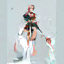
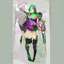
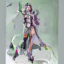
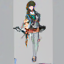
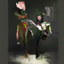
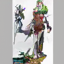
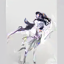
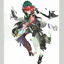

next display in 900 seconds; et now 42333.2641723156 because 3110.0160343647003 + 39224.413696050644
here ema.decay was 0.9981533147438535
ES is  42333.2641723156


EDM Epoch 283 Loss: 0.1001 ['0.33', '0.22', '0.13', '0.08', '0.07', '0.14', '0.20', '0.54']:  22%|██▏       | 87/401 [00:32<04:58,  1.05it/s]

✅ Saved checkpoint: checkpoints/fantasy_64_CorticalRefinerUNet_4_2_big.pth
✅ Saved checkpoint: checkpoints/fantasy_64_CorticalRefinerUNet_4_2_big.pth_ema.pth
saved checkpoint


EDM Epoch 283 Loss: 0.0846 ['0.35', '0.23', '0.12', '0.08', '0.07', '0.12', '0.28', '0.55']: 100%|██████████| 401/401 [02:23<00:00,  2.79it/s]
EDM Epoch 284 Loss: 0.0805 ['0.37', '0.21', '0.12', '0.08', '0.07', '0.12', '0.27', '0.48']: 100%|██████████| 401/401 [02:20<00:00,  2.86it/s]
EDM Epoch 285 Loss: 0.0798 ['0.36', '0.20', '0.14', '0.08', '0.07', '0.12', '0.23', '0.46']: 100%|██████████| 401/401 [02:20<00:00,  2.85it/s]
EDM Epoch 286 Loss: 0.0879 ['0.34', '0.22', '0.13', '0.08', '0.07', '0.12', '0.25', '0.51']:  53%|█████▎    | 214/401 [01:16<01:06,  2.80it/s]


KeyboardInterrupt: 

In [ ]:
#  64->32->16->8
img_size = 64
m = CorticalRefinerUNet_4_2_big(img_size=img_size)
print(show_model_info(m))
run_one_experiment(m,"fantasy",img_size=img_size,max_training_time=60*60*24*3)


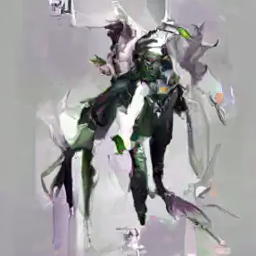
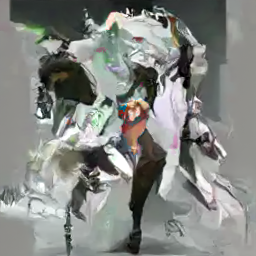
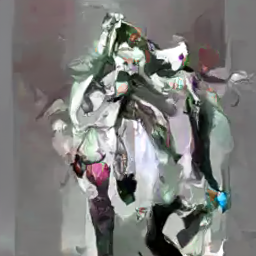
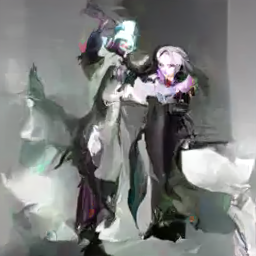
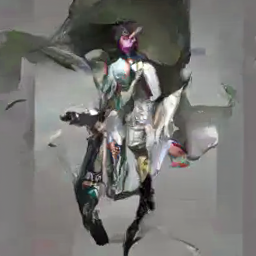
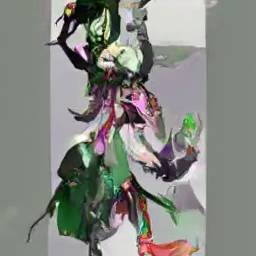
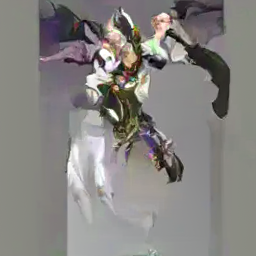
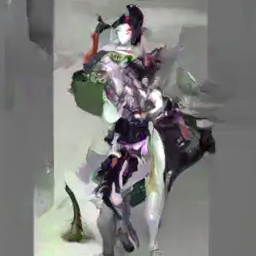

next display in 900 seconds; et now 245240.42452955246 because 67907.43961071968 + 177347.30338430405
here ema.decay was 0.9998844821426083
ES is  245240.42452955246
✅ Saved checkpoint: checkpoints/fantasy_256_CorticalRefinerUNet_4_2_big.pth


EDM Epoch 86 Loss: 0.0253 ['0.26', '0.14', '0.07', '0.04', '0.03', '0.06', '0.16', '0.52']:  88%|████████▊ | 5616/6407 [29:18<1:07:15,  5.10s/it]

✅ Saved checkpoint: checkpoints/fantasy_256_CorticalRefinerUNet_4_2_big.pth_ema.pth
saved checkpoint


EDM Epoch 86 Loss: 0.0391 ['0.25', '0.11', '0.06', '0.04', '0.03', '0.07', '0.24', '0.57']:  93%|█████████▎| 5977/6407 [31:21<02:30,  2.86it/s]  

In [ ]:
img_size = 256
m = CorticalRefinerUNet_4_2_big(img_size=img_size)
print(show_model_info(m))
run_one_experiment(m,"fantasy",img_size=img_size,max_training_time=60*60*24*3)

In [ ]:
img_size = 256
m = CorticalRefinerUNet_3_2(img_size=img_size)
print(show_model_info(m))
run_one_experiment(m,"fantasy",img_size=img_size,max_training_time=60*60*24*2+60*60*24)

In [ ]:
img_size = 256
m = CorticalRefinerUNet_3_2(img_size=img_size)
print(show_model_info(m))
run_one_experiment(m,"fantasy",img_size=img_size,max_training_time=60*60*24*2+60*60*8)

In [ ]:
m = None; clear_torch_mem()
img_size = 128

for h in [1,2,4,6,8,10,12]:
    m = CorticalRefinerUNet_5_0(img_size=img_size)
    clear_torch_mem()
    run_one_experiment(m,"fantasy",img_size=img_size,max_training_time=60*60*h)
    m = CorticalRefinerUNet_4_1(img_size=img_size)
    clear_torch_mem()
    run_one_experiment(m,"fantasy",img_size=img_size,max_training_time=60*60*h)
    m = CorticalRefinerUNet_3_2(img_size=img_size)
    clear_torch_mem()
    run_one_experiment(m,"fantasy",img_size=img_size,max_training_time=60*60*h)
    m = CorticalRefinerUNet_2_3(img_size=img_size)
    clear_torch_mem()
    run_one_experiment(m,"fantasy",img_size=img_size,max_training_time=60*60*h)
    m = CorticalRefinerUNet_1_4(img_size=img_size)
    clear_torch_mem()
    run_one_experiment(m,"fantasy",img_size=img_size,max_training_time=60*60*h)


## TRY THE MINIMAL ONE

In [ ]:
import torch
import torch.nn as nn
import einx


class DiffusionTransformer(nn.Module):

    def __init__(self, img_size=28, patch_size=4, in_channels=3, embed_dim=256, num_heads=4, num_layers=4):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_channels = in_channels
        self.num_patches = (img_size // patch_size) ** 2  # 49 patches

        self.time_embed = self.time_embed = nn.Sequential(
            nn.Linear(1, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )

        # self.patch_embed = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.patch_embed = nn.Linear(in_channels * patch_size * patch_size, embed_dim)

        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, embed_dim) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.0,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.final_norm = nn.LayerNorm(embed_dim)

        self.patch_decoder = nn.Linear(embed_dim, in_channels * patch_size * patch_size)

    def forward(self, x, t):

        B = x.shape[0]
        h = w = self.img_size // self.patch_size
        p = self.patch_size
        c = self.in_channels

        t_emb = self.time_embed(einx.rearrange('b -> b 1', t.float()))  # (B, emb_dim)

        # Patchify using pure einx - no conv!
        # (B, c, 28, 28) -> (B, 49, c*16) where 49 patches, c*16 pixel values per patch
        patches = einx.rearrange(
            'b c (h p1) (w p2) -> b (h w) (c p1 p2)',
            x,
            p1=self.patch_size,
            p2=self.patch_size
        )

        # Linear projection: (B, 49, c*16) -> (B, 49, embed_dim)
        tokens = self.patch_embed(patches)

        tokens = tokens + self.pos_embed + t_emb.unsqueeze(1)

        tokens = self.transformer(tokens)  # (B, num_patches, embed_dim)

        tokens = self.final_norm(tokens)
        patches_flat = self.patch_decoder(tokens)  # (B, num_patches, c*patch_size^2)

        img = einx.rearrange('b (h w) (c p1 p2) -> b c (h p1) (w p2)',
                             patches_flat, h=h, w=w, p1=p, p2=p, c=c)

        return img



In [ ]:

# Create model
model = DiffusionTransformer(
    img_size=16,
    patch_size=4,
    in_channels=3,
    embed_dim=256,
    num_heads=4,
    num_layers=4
)
#!rm checkpoints/*DiffusionTransformer*

print(model)
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
run_one_experiment(model,"mnist_scaled",img_size=16,max_training_time=60*60*5)


In [ ]:
m = CorticalRefinerUNet_1_2(img_size=img_size)
m.__class__.__name__

'CorticalRefinerUNet_1_2'

In [ ]:
for hours in [48]:
    for mn in model_names:
        print(mn)
        img_size = 128
        m=get_model(mn,img_size)
        run_one_experiment(m,"cats_and_dogs",img_size=img_size,max_training_time=60*60*hours)
        m = None
        clear_torch_mem()

In [ ]:
1/0

In [ ]:
# # This model from deepseek has the most interesting failure mode.
# # Good eyes; good global structure, but failures in the middle resolutions.

# from elucidated_diffusion.models.deepseek_try3 import OptionA_FixedBottleneckUNet
# m = OptionA_FixedBottleneckUNet()
# rf = None# "checkpoints/OptionA_FixedBottleneckUNet_2025-12-23_07-24-53_pokemon_efficient.pth"
# run_one_experiment(m,"fantasy",img_size=128,max_training_time=60*60*4,resume_from=rf)

In [ ]:
# from elucidated_diffusion.models.claude_gaussian_splatting_unet import GaussianSplattingDiffusionUNet
# m = GaussianSplattingDiffusionUNet()
# rf = None
# run_one_experiment(m,"pokemon",img_size=128,max_training_time=60*60*8,resume_from=rf)

# Inference

In [ ]:
model_names = [
    'claude_skip_attention',
    'claude_semantic_coordinator',
    'deepseek_fixed_bottleneck',
    'copilot_unet_with_structure_map',
    'hybrid_cascaded_vit',
    "chatgpt_diffusion",
    'baseline_minimal',
    #'claude_gradual_transition', # too memory hungry at 128?
    #'minimal_single_resolution', #  too dumb
]
dataset_name='pokemon'
for mn in model_names:
    img_size = 128
    m=get_model(mn,img_size)
    m.to(device)
    model_name = m.__class__.__name__
    checkpoint_path = f'checkpoints/{dataset_name}_{img_size}_{model_name}.pth'
    model_edm,optimizer_edm,metadata = load_checkpoint(model=m, optimizer=None, path=checkpoint_path)
    elapsed_time = metadata.get("elapsed_time",0)
    dt = time.strftime('%H:%M:%S', time.gmtime(elapsed_time))
    print(checkpoint_path,metadata)
    h = sample_html(m, img_shape=(3,img_size,img_size), title=f"{model_name} at {dt}", batch_size=4, min_height=128)
    ipd.display(ipd.HTML(h))
    checkpoint_path = f'checkpoints/{dataset_name}_{img_size}_{model_name}.pth_ema.pth'
    model_edm,optimizer_edm,metadata = load_checkpoint(model=m, optimizer=None, path=checkpoint_path)
    h = sample_html(m, img_shape=(3,img_size,img_size), title=f"{model_name} EMA at {dt}", batch_size=4, min_height=128)
    ipd.display(ipd.HTML(h))


    #print(m)


In [ ]:
# def show_model_info(model_edm):
#     # Totals
#     total_params = sum(p.numel() for p in model_edm.parameters())
#     trainable_params = sum(p.numel() for p in model_edm.parameters() if p.requires_grad)
#     print(f"Total parameters: {total_params:,}")
#     print(f"Trainable parameters: {trainable_params:,} ({trainable_params/total_params*100:.2f}%)\n")
    
#     # Breakdown by top-level module (first name segment)
#     by_module = {}
#     for name, p in model_edm.named_parameters():
#         top = name.split('.')[0]
#         tot = p.numel()
#         by_module.setdefault(top, [0, 0])
#         by_module[top][0] += tot
#         if p.requires_grad:
#             by_module[top][1] += tot
    
#     # Print sorted breakdown
#     print("Parameter breakdown by top-level module:")
#     for mod, (tot, train) in sorted(by_module.items(), key=lambda x: x[1][0], reverse=True):
#         pct = train / tot * 100 if tot else 0.0
#         print(f"{mod:35} total: {tot:12,}   trainable: {train:12,}   trainable%: {pct:6.2f}")
    
#     # Show largest individual parameter tensors for quick inspection
#     print("\nTop 10 largest parameter tensors:")
#     largest = sorted(model_edm.named_parameters(), key=lambda x: x[1].numel(), reverse=True)[:10]
#     for name, p in largest:
#         print(f"{name:60} shape: {tuple(p.shape)} params: {p.numel():12,}  {'train' if p.requires_grad else 'frozen'}")



# Guided generation

In [ ]:
import torch
import numpy as np
from PIL import Image

def pil_to_tensor(pil_img):
    img = pil_img.resize((128, 128), Image.BILINEAR)
    arr = np.array(img, dtype=np.float32) / 255.0
    return torch.tensor(arr * 2.0 - 1.0).unsqueeze(0)  # Scale to [-1, 1]

def tensor_to_pil(arr):
    arr = (arr - arr.min()) / (arr.max() - arr.min())
    return transforms.ToPILImage()(arr)

def show_results(original,noised,denoised,title=None):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    if title:
            fig.suptitle(main_title, fontsize=16)
    axes[0].imshow(tensor_to_pil(original), cmap="gray")
    axes[1].imshow(tensor_to_pil(noised), cmap="gray")
    axes[2].imshow(tensor_to_pil(denoised), cmap="gray")
    axes[0].set_title("original")
    axes[1].set_title("noised")
    axes[2].set_title("denoised")
    [ax.axis("off") for ax in axes]
    plt.show()

In [ ]:



# def add_noise(clean_tensor, noise_sigma):
#     from scipy.ndimage import gaussian_filter
#     noise = np.random.randn(*clean_tensor.shape) * noise_sigma
#     noised = (clean_tensor + noise)
#     return torch.tensor(noised).float()

# def denoise(noisy_tensor, model, num_steps=18, start_sigma=1.0):
#     device = next(model.parameters()).device
#     sigma_data = 0.5
#     sigma_min = 0.002
#     rho = 7.0
    
#     x = torch.from_numpy(noisy_tensor.numpy()).unsqueeze(0).to(device)
    
#     step_indices = torch.arange(num_steps, dtype=torch.float64, device=device)
#     t_steps = (start_sigma ** (1/rho) + step_indices / (num_steps - 1) * 
#               (sigma_min ** (1/rho) - start_sigma ** (1/rho))) ** rho
#     t_steps = torch.cat([t_steps, torch.zeros_like(t_steps[:1])])
    
#     for i, (t_cur, t_next) in enumerate(zip(t_steps[:-1], t_steps[1:])):
#         sigma = t_cur.float()
#         c_skip = sigma_data ** 2 / (sigma ** 2 + sigma_data ** 2)
#         c_out = sigma * sigma_data / (sigma ** 2 + sigma_data ** 2).sqrt()
#         c_in = 1 / (sigma_data ** 2 + sigma ** 2).sqrt()
#         c_noise = sigma.log() / 4
        
#         F_x = model(c_in * x, c_noise.unsqueeze(0))
#         denoised = c_skip * x + c_out * F_x
#         d_cur = (x - denoised) / t_cur
#         x = x + (t_next - t_cur) * d_cur
        
#         if i < num_steps - 1:
#             sigma_next = t_next.float()
#             c_skip_next = sigma_data ** 2 / (sigma_next ** 2 + sigma_data ** 2)
#             c_out_next = sigma_next * sigma_data / (sigma_next ** 2 + sigma_data ** 2).sqrt()
#             c_in_next = 1 / (sigma_data ** 2 + sigma_next ** 2).sqrt()
#             c_noise_next = sigma_next.log() / 4
            
#             F_x_next = model(c_in_next * x, c_noise_next.unsqueeze(0))
#             denoised_next = c_skip_next * x + c_out_next * F_x_next
#             d_prime = (x - denoised_next) / t_next
#             x = x + (t_next - t_cur) * (0.5 * d_cur + 0.5 * d_prime)
    
#     return x.squeeze().cpu()#.numpy(force=True)


# import random

# test_dataset,test_loader = get_dataset_and_loader(dataset_name,img_size)

# idx = random.randint(0,len(test_dataset))

# def get_trained_model(mn,img_size,dataset_name):
#     m=get_model(mn,img_size)
#     m.to(device)
#     model_name = m.__class__.__name__
#     checkpoint_path = f'checkpoints/{dataset_name}_{img_size}_{model_name}.pth'
#     model_edm,optimizer_edm,metadata = load_checkpoint(model=m, optimizer=None, path=checkpoint_path)
#     model_edm.eval()
#     return model_edm

# model = get_trained_model('claude_semantic_coordinator',128,'fantasy')

# def try_noise_levels(idx,noise_sigma=1):
#     original = test_dataset[idx][0]
#     noised = add_noise(original,noise_sigma)
#     denoised = denoise(noised,model_edm,num_steps=18,start_sigma=noise_sigma)
#     title = f"noise_sigma={noise_sigma}"
#     show_results(original,noised,denoised)

# try_noise_levels(idx,0.1)
# try_noise_levels(idx,1)
# try_noise_levels(idx,80)


In [ ]:
def add_noise(clean_tensor, noise_sigma):
    """
    Add noise at specified sigma level.
    Note: clean_tensor should be in range [-1, 1] (matching training)
    """
    noise = torch.randn_like(clean_tensor)
    noised = clean_tensor + noise_sigma * noise
    return noised

def denoise(noisy_tensor, model, num_steps=18, start_sigma=1.0):
    device = next(model.parameters()).device
    sigma_data = 0.5
    sigma_min = 0.002
    rho = 7.0
    
    # Ensure proper tensor handling
    if not isinstance(noisy_tensor, torch.Tensor):
        x = torch.from_numpy(noisy_tensor).float()
    else:
        x = noisy_tensor.clone()
    
    # Add batch dimension if needed
    if x.dim() == 3:
        x = x.unsqueeze(0)
    
    x = x.to(device)
    
    # Create schedule starting from start_sigma down to sigma_min
    step_indices = torch.arange(num_steps, dtype=torch.float64, device=device)
    t_steps = (start_sigma ** (1/rho) + step_indices / (num_steps - 1) * 
              (sigma_min ** (1/rho) - start_sigma ** (1/rho))) ** rho
    t_steps = torch.cat([t_steps, torch.zeros_like(t_steps[:1])])
    
    # NO SCALING HERE - the input should already be at the right noise level
    
    # Main denoising loop
    x_next = x
    for i, (t_cur, t_next) in enumerate(zip(t_steps[:-1], t_steps[1:])):
        x_cur = x_next  # Match the pattern from working code
        
        sigma = t_cur.float()
        c_skip = sigma_data ** 2 / (sigma ** 2 + sigma_data ** 2)
        c_out = sigma * sigma_data / (sigma ** 2 + sigma_data ** 2).sqrt()
        c_in = 1 / (sigma_data ** 2 + sigma ** 2).sqrt()
        c_noise = sigma.log() / 4
        
        # Model prediction
        F_x = model(c_in * x_cur, c_noise.expand(x_cur.shape[0]))
        denoised = c_skip * x_cur + c_out * F_x
        d_cur = (x_cur - denoised) / t_cur
        x_next = x_cur + (t_next - t_cur) * d_cur
        
        # Heun's 2nd order correction
        if i < num_steps - 1:
            sigma_next = t_next.float()
            c_skip_next = sigma_data ** 2 / (sigma_next ** 2 + sigma_data ** 2)
            c_out_next = sigma_next * sigma_data / (sigma_next ** 2 + sigma_data ** 2).sqrt()
            c_in_next = 1 / (sigma_data ** 2 + sigma_next ** 2).sqrt()
            c_noise_next = sigma_next.log() / 4
            
            F_x_next = model(c_in_next * x_next, c_noise_next.expand(x_next.shape[0]))
            denoised_next = c_skip_next * x_next + c_out_next * F_x_next
            d_prime = (x_next - denoised_next) / t_next
            x_next = x_cur + (t_next - t_cur) * (0.5 * d_cur + 0.5 * d_prime)
    
    return x_next.squeeze(0).cpu()

In [ ]:
try_noise_levels(idx,0.1)
try_noise_levels(idx,1)
try_noise_levels(idx,3)
try_noise_levels(idx,5)

In [ ]:
# Check data range
original = test_dataset[idx][0]
print(f"Original range: [{original.min():.3f}, {original.max():.3f}]")

# If it's in [0, 1], convert to [-1, 1]
if original.min() >= 0:
    original = original * 2 - 1

noised = add_noise(original, 80.0)
print(f"Noised range: [{noised.min():.3f}, {noised.max():.3f}]")
print(f"Noised std: {noised.std():.3f}")  # Should be around 80

denoised = denoise(noised, model, num_steps=18, start_sigma=80.0)

In [ ]:
def generate_images(model_edm, num_steps=15, batch_size=20, img_shape = (3,64,64)):
    to_pil = transforms.ToPILImage()
    with torch.no_grad():
        samples = edm_ancestral_sampling_for_diffusion(model_edm, num_steps=num_steps, batch_size=batch_size, img_shape=img_shape).cpu()
        samples = (samples + 1) / 2  # scale from [-1,1] to [0,1]
        samples = samples.clamp(0, 1)
        pil_images = [to_pil(img) for img in samples]
    return pil_images
generate_images(model,15,4,img_shape=(3,128,128))[0]